In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy import stats
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import re
import matplotlib.colors as mcolors
import networkx as nx
import itertools

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy
from scipy.stats import mannwhitneyu
from itertools import combinations

from collections import defaultdict
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import euclidean
import matplotlib.lines as mlines

from sklearn.mixture import GaussianMixture
import matplotlib.gridspec as gridspec

from scipy.linalg import eigvalsh

from matplotlib.lines import Line2D

sc.settings.verbosity = 2

# Load data

In [2]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.43 GB, difference +2.43 GB
CPU times: user 564 ms, sys: 1.68 s, total: 2.25 s
Wall time: 5.23 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [7]:
adata.var.loc['MYOD1']

gene_id                     ENSG00000129152
gene_type                    protein_coding
Chromosome                            chr11
Start                              17719570
End                                17722136
mt                                    False
ribo                                  False
n_cells_by_counts                      6036
mean_counts                        1.413255
log1p_mean_counts                  0.880976
pct_dropout_by_counts             69.602659
total_counts                        28063.0
log1p_total_counts                10.242243
n_counts                            24379.0
mean                               0.465746
std                                0.777078
highly_variable                        True
highly_variable_rank                  903.0
means                              1.489522
variances                           9.13931
variances_norm                     1.106414
highly_variable_nbatches                  1
highly_variable_no_cc           

# Load gene sets

In [38]:
# TFs
fpath = "../../resources/HumanTF_v_1.01.csv"

tdf = pd.read_csv(fpath)

tdf = tdf[['HGNC symbol', 'Is TF?']]
tdf = tdf.rename(columns={'HGNC symbol': 'gene_name', 'Is TF?': 'is_tf'})
tdf = tdf[tdf['is_tf'] == 'Yes']
tdf = tdf.drop_duplicates(subset='gene_name')
display(tdf.head())

# extract unique TFs
tf_list = tdf['gene_name'].unique()
print(len(tf_list))

tf_list = [g for g in tf_list if g in adata.var_names]

print(len(tf_list))

,gene_name,is_tf
0,TFAP2A,Yes
1,TFAP2B,Yes
2,TFAP2C,Yes
3,TFAP2D,Yes
4,TFAP2E,Yes


1639
1358


In [8]:
path = "../../resources/HouseKeeping-GeneCards.csv"

hdf = pd.read_csv(path)
print(hdf.shape)

hk_genes = hdf['Gene Symbol'].unique()
print(f"N housekeeping genes: {len(hk_genes)}")

hdf.head()

(634, 8)
N housekeeping genes: 634


,Gene Symbol,Description,Category,Uniprot ID,Gifts,GC Id,Relevance score,GeneCards Link
0,GAPDH,Glyceraldehyde-3-Phosphate Dehydrogenase,Protein Coding,P04406,64,GC12P080272,6.024998,https://www.genecards.org/cgi-bin/carddisp.pl?...
1,B2M,Beta-2-Microglobulin,Protein Coding,P61769,62,GC15P044711,3.963092,https://www.genecards.org/cgi-bin/carddisp.pl?...
2,HPRT1,Hypoxanthine Phosphoribosyltransferase 1,Protein Coding,P00492,60,GC0XP134460,3.547013,https://www.genecards.org/cgi-bin/carddisp.pl?...
3,SURF4,Surfeit 4,Protein Coding,O15260,50,GC09M133361,2.606426,https://www.genecards.org/cgi-bin/carddisp.pl?...
4,TBP,TATA-Box Binding Protein,Protein Coding,P20226,62,GC06P170554,2.571569,https://www.genecards.org/cgi-bin/carddisp.pl?...


In [3]:
# MYOD/PRRX1 targets and influencers from the HWG

path1 = "../../resources/HWG_MYOD_Influencers.csv"
path2 = "../../resources/HWG_MYOD_Target.csv"
path3 = "../../resources/HWG_PRRX1_Influencers.csv"
path4 = "../../resources/HWG_PRRX1_Target.csv"

def load_and_rename(path, gene, role):
    df = pd.read_csv(path)
    df = df.rename(columns={
        f"{gene} {role}": "gene",
        f"{gene} {role} ID": "gene_id",
        f"{gene} {role} degree centrality": "degree_centrality",
        f"{gene} {role} Eigenvector centrality": "eigenvector_centrality"
    })
    return df

myod_inf = load_and_rename(path1, "MYOD", "Influencer")
myod_tar = load_and_rename(path2, "MYOD", "Target")
prrx_inf = load_and_rename(path3, "PRRX1", "Influencer")
prrx_tar = load_and_rename(path4, "PRRX1", "Target")

for name, df in zip(
    ["MYOD Influencers", "MYOD Targets", "PRRX1 Influencers", "PRRX1 Targets"],
    [myod_inf, myod_tar, prrx_inf, prrx_tar]
):
    print(f"{name}: {df['gene'].nunique()} unique genes ({df.shape[0]} rows)")
    
    
myod_tar.head()

MYOD Influencers: 170 unique genes (170 rows)
MYOD Targets: 544 unique genes (544 rows)
PRRX1 Influencers: 78 unique genes (78 rows)
PRRX1 Targets: 195 unique genes (195 rows)


,gene,gene_id,degree_centrality,eigenvector_centrality
0,GAPDH,ENSG00000111640,0.180,0.086
1,TP53,ENSG00000141510,0.171,0.079
2,ACTB,ENSG00000075624,0.151,0.074
3,MYC,ENSG00000136997,0.140,0.073
4,AKT1,ENSG00000142208,0.146,0.065


In [115]:
g1 = myod_tar['gene'].unique()
g2 = prrx_tar['gene'].unique()


g3 = list(set(g1) & set(g2))
print(f"Shared target genes: {len(g3)}\n")

print(", ".join(sorted(g3)))

Shared target genes: 50

BGLAP, BMP4, CAV1, CDH1, CDH2, COL1A1, CTNNB1, CXCL12, DCN, EBF2, FGF10, FGF18, FGF7, FGF8, FN1, FOXA2, GATA4, GLI1, HAND2, KLF4, MEIS2, MEOX2, MSX1, MYC, MYOZ1, NES, PAX9, PDGFRA, PDGFRB, PITX2, POU5F1, RUNX2, SCX, SGCD, SHH, SIX1, SNAI1, SNAI2, SOX10, SOX2, SOX9, SP7, SRF, TAL1, TBX5, TGFB1, THY1, TWIST1, TWIST2, WNT5A


In [116]:
g1 = myod_inf['gene'].unique()
g2 = prrx_inf['gene'].unique()


g3 = list(set(g1) & set(g2))
print(f"Shared influencer genes: {len(g3)}\n")

print(", ".join(sorted(g3)))

Shared influencer genes: 27

EBF2, FOXA2, GATA4, GLI1, HAND2, KLF4, MEIS2, MEOX2, MSX1, MYC, PAX9, PITX2, POU5F1, RUNX2, SCX, SIX1, SNAI1, SNAI2, SOX10, SOX2, SOX9, SP7, SRF, TAL1, TBX5, TWIST1, TWIST2


In [9]:
# Add columns 

# myod_inf['is_tf'] = myod_inf['gene'].isin(tf_list)

myod_tar['is_tf'] = myod_tar['gene'].isin(tf_list)
myod_tar['is_hk'] = myod_tar['gene'].isin(hk_genes)

print(f"TFs: {myod_tar['is_tf'].value_counts()}")
print(f"Housekeeping: {myod_tar['is_hk'].value_counts()}")

myod_tar.head()

TFs: is_tf
False    374
True     170
Name: count, dtype: int64
Housekeeping: is_hk
False    475
True      69
Name: count, dtype: int64


,gene,gene_id,degree_centrality,eigenvector_centrality,is_tf,is_hk
0,GAPDH,ENSG00000111640,0.180,0.086,False,True
1,TP53,ENSG00000141510,0.171,0.079,True,True
2,ACTB,ENSG00000075624,0.151,0.074,False,True
3,MYC,ENSG00000136997,0.140,0.073,True,True
4,AKT1,ENSG00000142208,0.146,0.065,False,False


# Active MYOD targets

## In Control

In [ ]:
# do pseudobulk -- Y or N

h

In [73]:
# which of the MYOD targets are expressed in control?
myod_tar_genes = myod_tar['gene'].unique()
myod_tar_genes = [g for g in myod_tar_genes if g in adata.var_names]
print(f"In adata: {len(myod_tar_genes)}")

bdata = adata[adata.obs['pooled_condition'] == 'Control', myod_tar_genes].copy()

bdata.X = bdata.layers['log_norm'].copy()

# dense format
X = bdata.X if isinstance(bdata.X, np.ndarray) else bdata.X.toarray()

X_df = pd.DataFrame(X, index=bdata.obs_names, columns=bdata.var_names)

print(X_df.shape)
X_df.head()

In adata: 450
(6902, 450)


gene_name,GAPDH,TP53,ACTB,MYC,AKT1,TNF,CTNNB1,HSP90AA1,JUN,IL6,...,RAPSN,HES6,MOS,IGFN1,ANKRD2,MAMSTR,EXOC3L1,MRLN,MYMX,TMEM108
AAACCAAAGGGTAGCA_control,2.976743,0.0,3.841156,0.398843,0.000000,0.0,0.683198,3.257908,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.398843,0.0,0.0,0.0,0.0
AAACCAAAGTAAGGGT_control,2.980752,0.0,3.120410,0.000000,0.000000,0.0,0.000000,2.288399,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
AAACCATTCAGGTAGG_control,2.738784,0.0,3.929671,0.000000,0.692049,0.0,0.000000,2.600655,0.404733,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
AAACCATTCCAGCCCT_control,2.626294,0.0,3.364107,0.000000,0.919694,0.0,0.000000,1.837343,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
AAACCATTCGTGACCG_control,2.070503,0.0,3.120271,0.000000,0.000000,0.0,0.000000,1.954828,0.623851,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [75]:
def binarize_gene(expression_series, min_expressing_cells=10, expression_threshold=0):
    """
    Binarize expression for a single gene using GMM.
    Falls back to all-zero if the gene is not expressed in enough cells.
    
    Parameters
    ----------
    expression_series : pd.Series
        Log-normalized expression values for one gene across cells.
    min_expressing_cells : int
        Minimum number of cells with expression > expression_threshold
        required to attempt GMM fitting.
    expression_threshold : float
        Value above which a cell is considered to have any expression.
    """
    x = expression_series.values
    n_expressing = np.sum(x > expression_threshold)
    
    # If gene is essentially unexpressed, call everything inactive
    if n_expressing < min_expressing_cells:
        return pd.Series(0, index=expression_series.index)
    
    # Fit GMM only on non-zero values (optional but often better)
    gmm = GaussianMixture(n_components=2, random_state=42)
    gmm.fit(x.reshape(-1, 1))
    labels = gmm.predict(x.reshape(-1, 1))
    
    # Ensure label 1 = high expression component
    if gmm.means_[0] > gmm.means_[1]:
        labels = 1 - labels
    
    return pd.Series(labels, index=expression_series.index)


binary_df = X_df.apply(binarize_gene)
print(binary_df.shape)
binary_df.head()

(6902, 450)


gene_name,GAPDH,TP53,ACTB,MYC,AKT1,TNF,CTNNB1,HSP90AA1,JUN,IL6,...,RAPSN,HES6,MOS,IGFN1,ANKRD2,MAMSTR,EXOC3L1,MRLN,MYMX,TMEM108
AAACCAAAGGGTAGCA_control,1,0,1,1,0,0,1,1,0,0,...,0,0,0,0,0,1,0,0,0,0
AAACCAAAGTAAGGGT_control,1,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCATTCAGGTAGG_control,1,0,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
AAACCATTCCAGCCCT_control,1,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCATTCGTGACCG_control,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [76]:
# how many genes are all 0?
zero_cols_mask = (binary_df == 0).all(axis=0)

num_zero_cols = zero_cols_mask.sum()

zero_cols = binary_df.columns[zero_cols_mask].tolist()

print("Number of all-zero columns:", num_zero_cols)
# print("Columns with all zeros:", zero_cols)

Number of all-zero columns: 59


In [78]:
# fraction of cells expressing each gene
detection_rate = binary_df.mean()
print(detection_rate.shape)

pct_exp_threshold = 0.10

active = detection_rate > pct_exp_threshold
print(active.shape)
active.value_counts()

(450,)
(450,)


True     240
False    210
Name: count, dtype: int64

/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


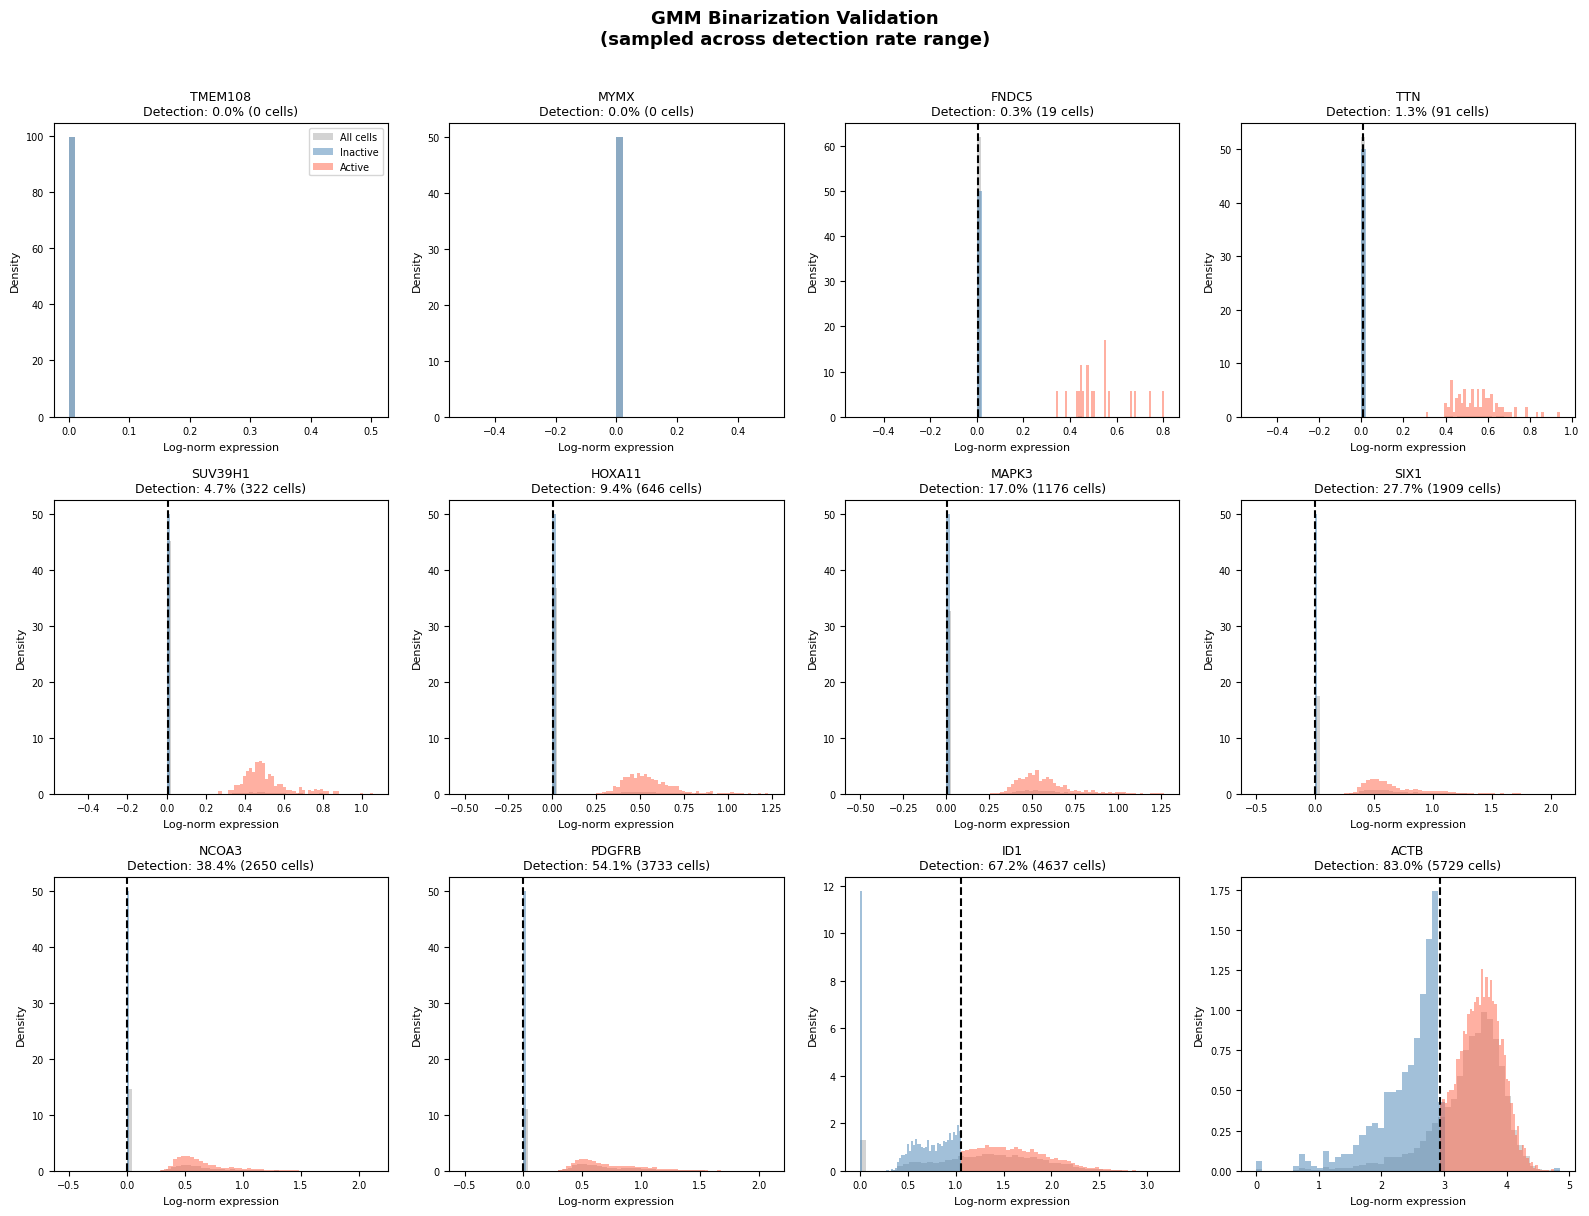

In [83]:
def plot_gmm_validation(expr_df, binary_df, n_genes=12, figsize=(16, 12), random_state=42):
    """
    Plot expression distributions with GMM threshold overlaid for a sample of genes.
    
    Parameters
    ----------
    expr_df : pd.DataFrame
        Original log-normalized expression dataframe (cells x genes)
    binary_df : pd.DataFrame
        Binarized dataframe output from binarize_gene
    n_genes : int
        Number of genes to sample and plot
    """
    # Sample genes - include a mix of high and low detection rate genes
    detection_rate = binary_df.mean()
    
    # Sample across the range of detection rates for a representative view
    sorted_genes = detection_rate.sort_values().index
    indices = np.linspace(0, len(sorted_genes) - 1, n_genes, dtype=int)
    sampled_genes = sorted_genes[indices]
    
    ncols = 4
    nrows = int(np.ceil(n_genes / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for i, gene in enumerate(sampled_genes):
        ax = axes[i]
        x = expr_df[gene].values
        n_active = binary_df[gene].sum()
        dr = detection_rate[gene]

        # Plot histogram of all cells
        ax.hist(x, bins=50, color='lightgray', edgecolor='none', density=True, label='All cells')

        # Overlay colored histograms for active/inactive calls
        ax.hist(x[binary_df[gene] == 0], bins=50, color='steelblue', alpha=0.5,
                density=True, label='Inactive')
        ax.hist(x[binary_df[gene] == 1], bins=50, color='tomato', alpha=0.5,
                density=True, label='Active')

        # Refit GMM to draw the boundary line
        if dr > 0:
            gmm = GaussianMixture(n_components=2, random_state=random_state)
            gmm.fit(x.reshape(-1, 1))
            x_range = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
            # Find the decision boundary (where posterior probs are equal)
            probs = gmm.predict_proba(x_range)
            boundary_idx = np.argmin(np.abs(probs[:, 0] - probs[:, 1]))
            boundary = x_range[boundary_idx][0]
            ax.axvline(boundary, color='black', linestyle='--', linewidth=1.5, label=f'Boundary: {boundary:.2f}')

        ax.set_title(f'{gene}\nDetection: {dr:.1%} ({int(n_active)} cells)', fontsize=9)
        ax.set_xlabel('Log-norm expression', fontsize=8)
        ax.set_ylabel('Density', fontsize=8)
        ax.tick_params(labelsize=7)
        if i == 0:
            ax.legend(fontsize=7)

    # Turn off unused axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('GMM Binarization Validation\n(sampled across detection rate range)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


plot_gmm_validation(X_df, binary_df, n_genes=12)

count    450.000000
mean       0.236241
std        0.252394
min        0.000000
25%        0.008766
50%        0.136555
75%        0.423863
max        0.830049
dtype: float64

Genes with >20% detection:
192

Genes with <5% detection:
165

Genes with <10% detection:
210


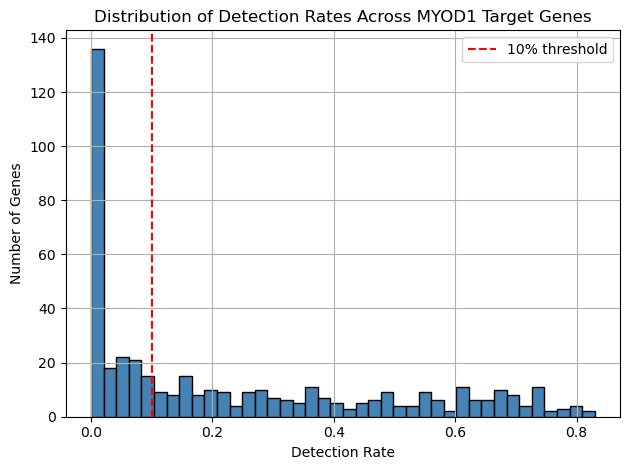

In [84]:
detection_rate = binary_df.mean()

print(detection_rate.describe())
print("\nGenes with >20% detection:")
print((detection_rate > 0.20).sum())
print("\nGenes with <5% detection:")
print((detection_rate < 0.05).sum())
print("\nGenes with <10% detection:")
print((detection_rate < 0.1).sum())

# Plot the distribution of detection rates across all genes
import matplotlib.pyplot as plt
detection_rate.hist(bins=40, edgecolor='black', color='steelblue')
plt.xlabel('Detection Rate')
plt.ylabel('Number of Genes')
plt.title('Distribution of Detection Rates Across MYOD1 Target Genes')
plt.axvline(0.10, color='red', linestyle='--', label='10% threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [93]:
print((detection_rate > 0.10).sum())

240


In [89]:
detection_rate = binary_df.mean()

# Bin genes into tiers
conditions = [
    detection_rate < 0.05,
    (detection_rate >= 0.05) & (detection_rate < 0.20),
    (detection_rate >= 0.20) & (detection_rate < 0.50),
    detection_rate >= 0.50
]

labels = ['Silent (0%)', 'Low (0-5%)', 'Moderate (5-20%)', 'High (20-50%)', 'Very High (>50%)']
gene_tier = pd.cut(detection_rate, bins=[-0.001, 0, 0.05, 0.20, 0.50, 1.0], labels=labels)

print(gene_tier.value_counts(sort=False))
print('\n')
print(gene_tier.value_counts(sort=False, normalize=True))

Silent (0%)          59
Low (0-5%)          106
Moderate (5-20%)     93
High (20-50%)       101
Very High (>50%)     91
Name: count, dtype: int64


Silent (0%)         0.131111
Low (0-5%)          0.235556
Moderate (5-20%)    0.206667
High (20-50%)       0.224444
Very High (>50%)    0.202222
Name: proportion, dtype: float64


## mmMYOD1

In [102]:
# which of the MYOD targets are expressed in control?
myod_tar_genes = myod_tar['gene'].unique()
myod_tar_genes = [g for g in myod_tar_genes if g in adata.var_names]
print(f"In adata: {len(myod_tar_genes)}")


conditions = ['Control', 'mmMYOD1', 'siPRRX1/mmMYOD1']

expr_mat = {}
binary_expr = {}


for cond in conditions:
    # subset for condition
    bdata = adata[adata.obs['pooled_condition'] == cond, myod_tar_genes].copy()

    bdata.X = bdata.layers['log_norm'].copy()

    # dense format
    X = bdata.X if isinstance(bdata.X, np.ndarray) else bdata.X.toarray()

    X_df = pd.DataFrame(X, index=bdata.obs_names, columns=bdata.var_names)

    print(X_df.shape)
    # display(X_df.head())
    
    # expr_mat[cond] = X_df

    # binarize
    binary_df = X_df.apply(binarize_gene)
    # display(binary_df.head())
    
    binary_expr[cond] = binary_df
    

In adata: 450
(6902, 450)
(2255, 450)
(3456, 450)


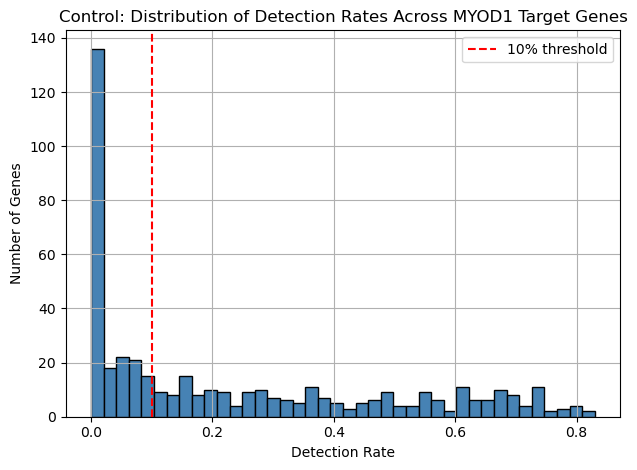

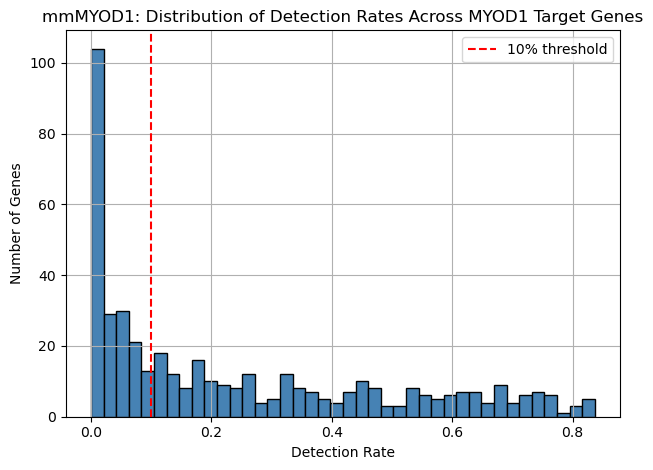

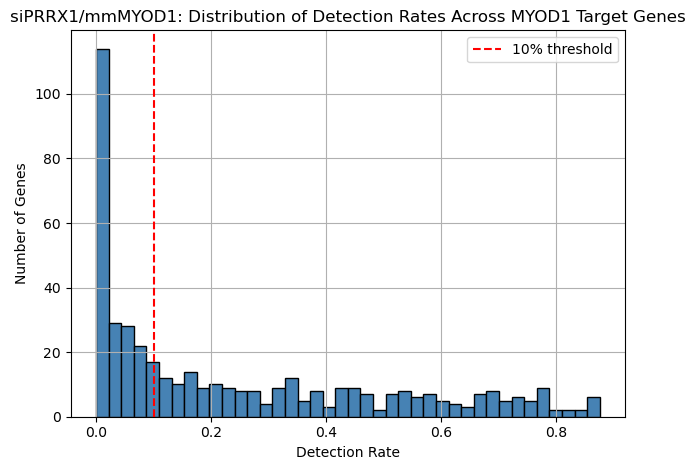

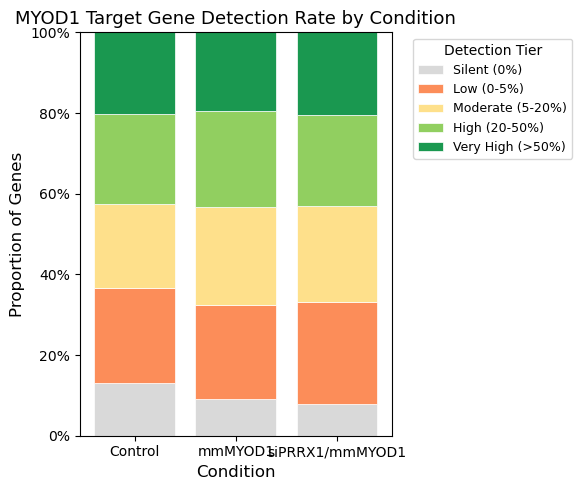

In [104]:
tier_labels = ['Silent (0%)', 'Low (0-5%)', 'Moderate (5-20%)', 'High (20-50%)', 'Very High (>50%)']
tier_proportions = {}

for cond in conditions:
    df = binary_expr[cond]
    detection_rate = df.mean()
    gene_tier = pd.cut(detection_rate, bins=[-0.001, 0, 0.05, 0.20, 0.50, 1.0], labels=tier_labels)
    tier_proportions[cond] = gene_tier.value_counts(sort=False, normalize=True)

    detection_rate.hist(bins=40, edgecolor='black', color='steelblue')
    plt.xlabel('Detection Rate')
    plt.ylabel('Number of Genes')
    plt.title(f'{cond}: Distribution of Detection Rates Across MYOD1 Target Genes')
    plt.axvline(0.10, color='red', linestyle='--', label='10% threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()


colors = ['#d9d9d9', '#fc8d59', '#fee08b', '#91cf60', '#1a9850']
prop_df = pd.DataFrame(tier_proportions).loc[tier_labels]
fig, ax = plt.subplots(figsize=(6, 5))
bottoms = np.zeros(len(prop_df.columns))
for tier, color in zip(tier_labels, colors):
    values = prop_df.loc[tier].values
    ax.bar(prop_df.columns, values, bottom=bottoms, color=color, label=tier, edgecolor='white', linewidth=0.5)
    bottoms += values

ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Proportion of Genes', fontsize=12)
ax.set_title('MYOD1 Target Gene Detection Rate by Condition', fontsize=13)
ax.legend(title='Detection Tier', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
# plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

In [105]:
prop_df

,Control,mmMYOD1,siPRRX1/mmMYOD1
Silent (0%),0.131111,0.091111,0.077778
Low (0-5%),0.235556,0.233333,0.253333
Moderate (5-20%),0.206667,0.242222,0.237778
High (20-50%),0.224444,0.237778,0.226667
Very High (>50%),0.202222,0.195556,0.204444


In [106]:
pct_exp_threshold = 0.10  # threshold for active/inactive

# First get the silent genes in Control
control_detection = binary_expr['Control'].mean()
silent_in_control = set(control_detection[control_detection <= pct_exp_threshold].index)
print(f"Genes inactive in Control: {len(silent_in_control)}")

# For each non-control condition, find genes that became active
unsilenced = {}
for cond in conditions:
    if cond == 'Control':
        continue
    cond_detection = binary_expr[cond].mean()
    active_in_cond = set(cond_detection[cond_detection > pct_exp_threshold].index)
    
    # Genes silent in control but active in this condition
    unsilenced[cond] = silent_in_control & active_in_cond
    print(f"\nGenes un-silenced in {cond}: {len(unsilenced[cond])}")
    print(sorted(unsilenced[cond]))

Genes inactive in Control: 210

Genes un-silenced in mmMYOD1: 28
['ACTC1', 'ACTN2', 'ACVR2A', 'ANKRD1', 'BHLHE41', 'BMAL1', 'BMP2', 'BTG2', 'CAPN3', 'CHRNA1', 'DHX35', 'DNMT3A', 'DTNA', 'EID2', 'ESR1', 'FBXO32', 'FOXO1', 'H2BC21', 'HDAC4', 'IL1B', 'KAT5', 'LIF', 'MSC', 'SMARCD3', 'SOX5', 'SOX9', 'USF1', 'ZIC1']

Genes un-silenced in siPRRX1/mmMYOD1: 18
['ACTN2', 'ACVR2A', 'ANKRD1', 'BHLHE41', 'BMAL1', 'BTG2', 'CAPN3', 'DHX35', 'ESR1', 'FBXO32', 'H2BC21', 'HDAC4', 'IL1B', 'KAT5', 'SOX5', 'SOX9', 'USF1', 'ZIC1']


In [55]:
# tmp = myod_tar[~myod_tar['is_hk']].copy()
# print(tmp.shape)

# tmp = tmp.sort_values(by='eigenvector_centrality', ascending=False)
# tmp.head(10)

n_top_genes = 19

myod_tar = myod_tar.sort_values(by='eigenvector_centrality', ascending=False)
myod_tar.head()


myod_tar_genes = myod_tar['gene'].unique()
print(f"Total genes: {len(myod_tar_genes)}")

myod_tar_genes = [g for g in myod_tar_genes if g in adata.var_names]
print(f"In adata: {len(myod_tar_genes)}")


gene_list = myod_tar_genes[:n_top_genes]

# add MYOD1
gene_list.append('MYOD1')

gene_list

Total genes: 544
In adata: 450


['GAPDH',
 'TP53',
 'ACTB',
 'MYC',
 'AKT1',
 'TNF',
 'CTNNB1',
 'HSP90AA1',
 'JUN',
 'IL6',
 'STAT3',
 'FN1',
 'NFKB1',
 'IL1B',
 'PTEN',
 'H3-3B',
 'BCL2',
 'HIF1A',
 'MAPK3',
 'MYOD1']

In [15]:
condition = 'Control'

bdata = adata[adata.obs['pooled_condition'] == 'Control', gene_list].copy()
print(bdata.shape)

bdata.X = bdata.layers['log_norm'].copy()

# dense format
X = bdata.X if isinstance(bdata.X, np.ndarray) else bdata.X.toarray()

X_df = pd.DataFrame(
    X,
    index=bdata.obs_names,
    columns=bdata.var_names,
)

print(X_df.shape)
display(X_df.head())

# correlations
R = X_df.corr()
print(R.shape)
display(R.head())

(6902, 20)
(6902, 20)


gene_name,GAPDH,TP53,ACTB,MYC,AKT1,TNF,CTNNB1,HSP90AA1,JUN,IL6,STAT3,FN1,NFKB1,PTEN,IL1B,H3-3B,BCL2,HIF1A,MAPK3,MYOD1
AAACCAAAGGGTAGCA_control,2.976743,0.0,3.841156,0.398843,0.000000,0.0,0.683198,3.257908,0.000000,0.0,0.398843,1.238519,0.000000,0.000000,0.0,1.997594,0.0,0.683198,0.000000,0.0
AAACCAAAGTAAGGGT_control,2.980752,0.0,3.120410,0.000000,0.000000,0.0,0.000000,2.288399,0.000000,0.0,0.000000,2.065652,0.000000,0.685291,0.0,2.550397,0.0,2.183215,0.000000,0.0
AAACCATTCAGGTAGG_control,2.738784,0.0,3.929671,0.000000,0.692049,0.0,0.000000,2.600655,0.404733,0.0,0.692049,2.770529,0.000000,0.000000,0.0,2.349387,0.0,1.502369,0.404733,0.0
AAACCATTCCAGCCCT_control,2.626294,0.0,3.364107,0.000000,0.919694,0.0,0.000000,1.837343,0.000000,0.0,0.562048,1.562621,0.562048,0.000000,0.0,1.182581,0.0,1.182581,0.000000,0.0
AAACCATTCGTGACCG_control,2.070503,0.0,3.120271,0.000000,0.000000,0.0,0.000000,1.954828,0.623851,0.0,0.623851,2.698512,0.000000,0.623851,0.0,2.433017,0.0,1.005108,0.000000,0.0


(20, 20)


gene_name,GAPDH,TP53,ACTB,MYC,AKT1,TNF,CTNNB1,HSP90AA1,JUN,IL6,STAT3,FN1,NFKB1,PTEN,IL1B,H3-3B,BCL2,HIF1A,MAPK3,MYOD1
gene_name,,,,,,,,,,,,,,,,,,,,
GAPDH,1.000000,-0.001881,0.371304,0.055054,0.065200,0.007938,-0.008577,0.279486,0.046472,-0.094834,-0.104656,0.012230,-0.038641,-0.072882,-0.070512,0.116478,0.016755,-0.051582,0.017629,NaN
TP53,-0.001881,1.000000,0.050417,0.018953,0.013781,0.014290,0.030453,0.061003,0.053915,0.034016,0.001442,0.010488,0.018110,0.022475,-0.010545,0.033647,-0.001363,0.000918,-0.007052,NaN
ACTB,0.371304,0.050417,1.000000,0.122428,0.081026,0.017433,0.026830,0.419012,0.050411,-0.086864,-0.046833,0.201843,-0.008352,-0.097600,-0.089340,0.085776,0.032976,0.022880,0.015568,NaN
MYC,0.055054,0.018953,0.122428,1.000000,0.005603,0.011203,0.021249,0.119149,0.032924,0.012659,0.004478,0.024814,0.006824,-0.013972,-0.018249,0.052838,0.023603,0.035147,-0.012164,NaN
AKT1,0.065200,0.013781,0.081026,0.005603,1.000000,0.012022,0.013868,0.066219,0.031216,-0.009404,0.019339,0.032977,0.001552,-0.022252,-0.033268,0.033733,-0.007365,-0.048296,0.008936,NaN


Nodes: 20, Edges: 6


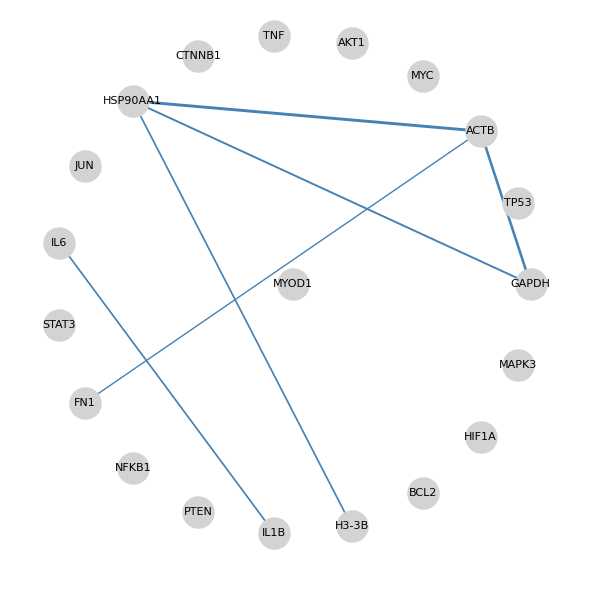

In [27]:
# # threhold correlation matrix
# threshold = 0.2

# G = nx.Graph()
# G.add_nodes_from(R.columns)

# # Stack the upper triangle
# upper = R.where(np.triu(np.ones(R.shape), k=1).astype(bool))
# edges = upper.stack()
# edges = edges[edges.abs() >= threshold]

# for (gene1, gene2), r in edges.items():
#     G.add_edge(gene1, gene2, weight=r)
# print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

# # plot graph
# def hub_and_spoke_layout(G, center_node):
#     pos = {}
#     other_nodes = [n for n in G.nodes if n != center_node]
#     n = len(other_nodes)
    
#     # Place center node at origin
#     pos[center_node] = np.array([0.0, 0.0])
    
#     # Place other nodes evenly around a circle
#     for i, node in enumerate(other_nodes):
#         angle = 2 * np.pi * i / n
#         pos[node] = np.array([np.cos(angle), np.sin(angle)])
    
#     return pos

# pos = hub_and_spoke_layout(G, 'MYOD1')


# edge_scale = 5

# edges = G.edges(data=True)
# weights = [d['weight'] for _, _, d in edges]
# colors = ['red' if w < 0 else 'steelblue' for w in weights]
# widths = [abs(w) * edge_scale for w in weights]  # scale for visibility


# plt.figure(figsize=(6, 6))
# nx.draw_networkx(
#     G, pos,
#     edge_color=colors,
#     width=widths,
#     node_size=500,
#     font_size=8,
#     node_color='lightgray',
# )


# plt.axis('off')
# plt.tight_layout()
# plt.show()

# Correlation matrices

In [56]:
def compute_corr_matrices(adata, gene_list, grouping_col, conditions):
    
    """
    Compute gene-gene correlation matrices for a specific set of genes per condition.
    
    gene_list: list of gene names 
    conditions: list of which conditions to compute corr matrices for
    
    """
    
    corr_matrices = {}
    
    for cond in conditions:
        bdata = adata[adata.obs[grouping_col] == cond, gene_list].copy()
        print(f"{cond} shape: {bdata.shape}")

        bdata.X = bdata.layers['log_norm'].copy()

        # dense format
        X = bdata.X if isinstance(bdata.X, np.ndarray) else bdata.X.toarray()

        X_df = pd.DataFrame(X, index=bdata.obs_names, columns=bdata.var_names)

        # correlations (pearson)
        R = X_df.corr()
        print(f"{cond}: corr matrix shape = {R.shape}")

        corr_matrices[cond] = R
        
    print('\nDone!')
        
    return corr_matrices



def hub_and_spoke_layout(G, center_node):
    pos = {}
    other_nodes = [n for n in G.nodes if n != center_node]
    n = len(other_nodes)
    
    # Place center node at origin
    pos[center_node] = np.array([0.0, 0.0])
    
    # Place other nodes evenly around a circle
    for i, node in enumerate(other_nodes):
        angle = 2 * np.pi * i / n
        pos[node] = np.array([np.cos(angle), np.sin(angle)])
    
    return pos


In [57]:
conditions = ['Control', 'mmMYOD1']

corr_matrices = compute_corr_matrices(adata, gene_list=gene_list, grouping_col='pooled_condition', conditions=conditions)

Control shape: (6902, 20)
Control: corr matrix shape = (20, 20)
mmMYOD1 shape: (2255, 20)
mmMYOD1: corr matrix shape = (20, 20)

Done!


In [29]:
# conditions = ['Control', 'mmMYOD1']

# corr_matrices = {}

# for cond in conditions:

#     bdata = adata[adata.obs['pooled_condition'] == cond, gene_list].copy()
#     print(f"{cond} shape: {bdata.shape}")

#     bdata.X = bdata.layers['log_norm'].copy()

#     # dense format
#     X = bdata.X if isinstance(bdata.X, np.ndarray) else bdata.X.toarray()

#     X_df = pd.DataFrame(
#         X,
#         index=bdata.obs_names,
#         columns=bdata.var_names,
#     )

#     print(X_df.shape)
#     # display(X_df.head())

#     # correlations
#     R = X_df.corr()

#     corr_matrices[cond] = R

Control shape: (6902, 20)
(6902, 20)
mmMYOD1 shape: (2255, 20)
(2255, 20)


Control — Nodes: 20, Edges: 2
mmMYOD1 — Nodes: 20, Edges: 23


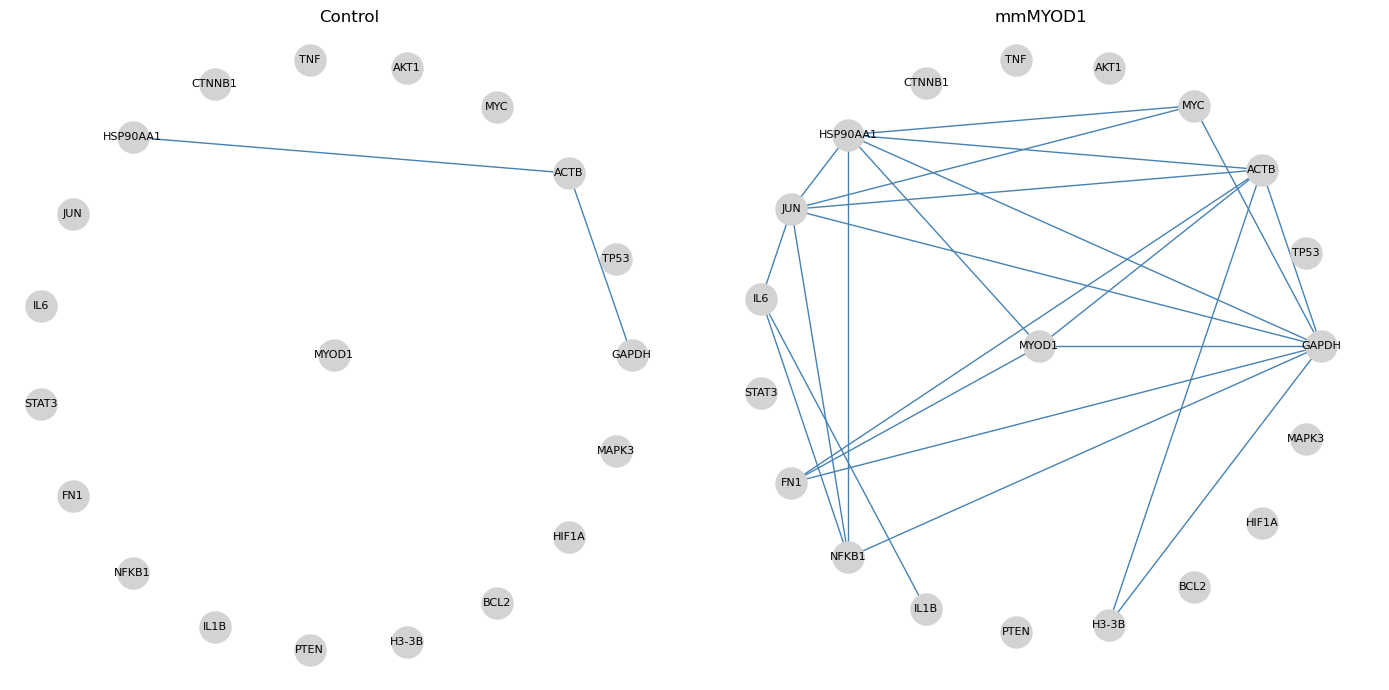

In [59]:
threshold = 0.3
edge_scale = 1

fig, axes = plt.subplots(1, 2, figsize=(14,7))

# theholds correlations --> sets active to 1
for ax, cond in zip(axes, conditions):
    
    R = corr_matrices[cond]

    G = nx.Graph()
    G.add_nodes_from(R.columns)

    # Stack the upper triangle
    upper = R.where(np.triu(np.ones(R.shape), k=1).astype(bool))
    edges = upper.stack()
    edges = edges[edges.abs() >= threshold]

    for (gene1, gene2), r in edges.items():
        G.add_edge(gene1, gene2, weight=1) # 
        
    print(f"{cond} — Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")


    pos = hub_and_spoke_layout(G, 'MYOD1')


    edges = G.edges(data=True)
    weights = [d['weight'] for _, _, d in edges]
    colors = ['red' if w < 0 else 'steelblue' for w in weights]
    widths = [abs(w) * edge_scale for w in weights]  # scale for visibility


    nx.draw_networkx(
        G, pos,
        ax=ax,
        edge_color=colors,
        width=widths,
        node_size=500,
        font_size=8,
        node_color='lightgray',
    )
    
    ax.set_title(cond, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

# TFs

In [60]:
fdata = adata[adata.obs['pooled_condition'] == 'Control', :].copy()

# Highest expressed?
fdata.X = fdata.layers['log_norm']

n_top_genes = 19

mean_expr = fdata[:, tf_list].X.mean(axis=0).A1
top_genes = [tf_list[i] for i in mean_expr.argsort()[::-1][:n_top_genes]]

top_genes.append('MYOD1')

print(top_genes)

['NME2', 'STAT1', 'DRAP1', 'YBX1', 'SP100', 'SON', 'HIF1A', 'PLSCR1', 'ARID5B', 'PA2G4', 'AEBP1', 'SP110', 'ATF4', 'CAMTA1', 'EEA1', 'STAT2', 'PRRX1', 'TBX3', 'FOS', 'MYOD1']


In [61]:
conditions = ['Control', 'mmMYOD1']

corr_matrices = compute_corr_matrices(adata, gene_list=top_genes, grouping_col='pooled_condition', conditions=conditions)

Control shape: (6902, 20)
Control: corr matrix shape = (20, 20)
mmMYOD1 shape: (2255, 20)
mmMYOD1: corr matrix shape = (20, 20)

Done!


Control — Nodes: 20, Edges: 2
mmMYOD1 — Nodes: 20, Edges: 14


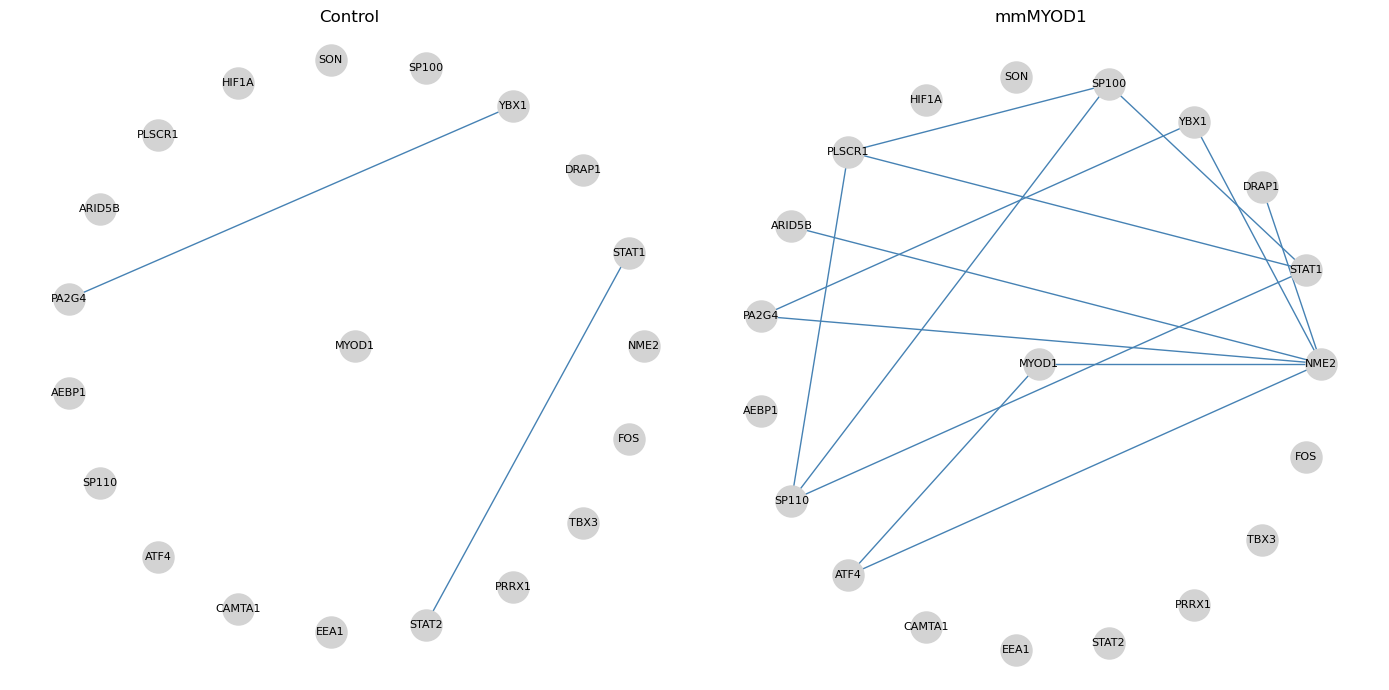

In [62]:
threshold = 0.3
edge_scale = 1

fig, axes = plt.subplots(1, 2, figsize=(14,7))


for ax, cond in zip(axes, conditions):
    
    R = corr_matrices[cond]

    G = nx.Graph()
    G.add_nodes_from(R.columns)

    # Stack the upper triangle
    upper = R.where(np.triu(np.ones(R.shape), k=1).astype(bool))
    edges = upper.stack()
    edges = edges[edges.abs() >= threshold]

    for (gene1, gene2), r in edges.items():
        G.add_edge(gene1, gene2, weight=1)
        
    print(f"{cond} — Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")


    pos = hub_and_spoke_layout(G, 'MYOD1')


    edges = G.edges(data=True)
    weights = [d['weight'] for _, _, d in edges]
    colors = ['red' if w < 0 else 'steelblue' for w in weights]
    widths = [abs(w) * edge_scale for w in weights]  # scale for visibility


    nx.draw_networkx(
        G, pos,
        ax=ax,
        edge_color=colors,
        width=widths,
        node_size=500,
        font_size=8,
        node_color='lightgray',
    )
    
    ax.set_title(cond, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# take all TFs in control, compute degree and eigenvector centrality? select top TFs ?

In [107]:
conditions = ['Control', 'mmMYOD1', 'siPRRX1/mmMYOD1']

corr_matrices = compute_corr_matrices(adata, gene_list=myod_tar_genes, grouping_col='pooled_condition', conditions=conditions)

Control shape: (6902, 450)
Control: corr matrix shape = (450, 450)
mmMYOD1 shape: (2255, 450)
mmMYOD1: corr matrix shape = (450, 450)
siPRRX1/mmMYOD1 shape: (3456, 450)
siPRRX1/mmMYOD1: corr matrix shape = (450, 450)

Done!


In [108]:
threshold = 0.3

centrality = {}

for cond in conditions:
    
    R = corr_matrices[cond]

    G = nx.Graph()
    G.add_nodes_from(R.columns)

    # Stack the upper triangle
    upper = R.where(np.triu(np.ones(R.shape), k=1).astype(bool))
    edges = upper.stack()
    edges = edges[edges >= threshold] # drop negatives, threshold positives
    # edges = edges[edges.abs() >= threshold]

    for (gene1, gene2), r in edges.items():
        G.add_edge(gene1, gene2, weight=1)
        
    print(f"{cond} — Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
    
    degree = nx.degree_centrality(G)
    eigen_cent = nx.eigenvector_centrality(G, max_iter=1000)#weight='weight', max_iter=1000)
    
    df = pd.DataFrame({
        'degree': degree,
        'eigenvector': eigen_cent,
    }).sort_values(by='eigenvector', ascending=False)
    
    centrality[cond] = df

Control — Nodes: 450, Edges: 73
mmMYOD1 — Nodes: 450, Edges: 236
siPRRX1/mmMYOD1 — Nodes: 450, Edges: 314


In [112]:
comparison = pd.concat(
    {cond: centrality[cond]['eigenvector'] for cond in conditions},
    axis=1
)
comparison.columns = conditions
comparison['delta_mmMYOD1'] = comparison['mmMYOD1'] - comparison['Control']
comparison['delta_HYB'] = comparison['siPRRX1/mmMYOD1'] - comparison['Control']

display(comparison.sort_values('delta_mmMYOD1', ascending=False).head())

top_mmyod = comparison.sort_values('delta_mmMYOD1', ascending=False).head(10).index
top_hyb = comparison.sort_values('delta_HYB', ascending=False).head(10).index

print(f"Top genes with gain in eigenvector centrality for mmMYOD1:\n {list(top_mmyod)}\n")
print(f"Top genes with gain in eigenvector centrality for HYB:\n {list(top_hyb)}")

,Control,mmMYOD1,siPRRX1/mmMYOD1,delta_mmMYOD1,delta_HYB
CD99,2.109924e-10,0.277554,0.257556,0.277554,0.257556
THY1,2.109924e-10,0.255479,0.244731,0.255479,0.244731
ITGB1,2.109924e-10,0.252506,0.257556,0.252506,0.257556
GAPDH,2.886586e-02,0.279757,0.267309,0.250891,0.238443
LDHA,2.109924e-10,0.250171,0.257556,0.250171,0.257556


Top genes with gain in eigenvector centrality for mmMYOD1:
 ['CD99', 'THY1', 'ITGB1', 'GAPDH', 'LDHA', 'CALD1', 'MYL9', 'CAV1', 'COL1A1', 'RPL30']

Top genes with gain in eigenvector centrality for HYB:
 ['ITGB1', 'CD99', 'LDHA', 'THY1', 'GAPDH', 'CAV1', 'RPL30', 'COL1A1', 'MYL9', 'MYL12B']


In [111]:
comparison = pd.concat(
    {cond: centrality[cond]['degree'] for cond in conditions},
    axis=1
)
comparison.columns = conditions
comparison['delta_mmMYOD1'] = comparison['mmMYOD1'] - comparison['Control']
comparison['delta_HYB'] = comparison['siPRRX1/mmMYOD1'] - comparison['Control']

display(comparison.sort_values('delta_mmMYOD1', ascending=False).head())

top_mmyod = comparison.sort_values('delta_mmMYOD1', ascending=False).head(10).index
top_hyb = comparison.sort_values('delta_HYB', ascending=False).head(10).index

print(f"Top genes with gain in degree centrality for mmMYOD1:\n {list(top_mmyod)}\n")
print(f"Top genes with gain in degree centrality for HYB:\n {list(top_hyb)}")

,Control,mmMYOD1,siPRRX1/mmMYOD1,delta_mmMYOD1,delta_HYB
GAPDH,0.002227,0.053452,0.053452,0.051225,0.051225
CD99,0.000000,0.046771,0.044543,0.046771,0.044543
THY1,0.000000,0.037862,0.042316,0.037862,0.042316
ITGB1,0.000000,0.037862,0.044543,0.037862,0.044543
LDHA,0.000000,0.037862,0.044543,0.037862,0.044543


Top genes with gain in degree centrality for mmMYOD1:
 ['GAPDH', 'CD99', 'THY1', 'ITGB1', 'LDHA', 'MYL9', 'CALD1', 'CAV1', 'RPL30', 'HDAC9']

Top genes with gain in degree centrality for HYB:
 ['GAPDH', 'CAV1', 'JUN', 'LDHA', 'ITGB1', 'CD99', 'THY1', 'ATF3', 'HDAC9', 'RPL30']
